In [2]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("data\Current-macroeconomic-situation-Tables-Based-on-Six-Month-data-of-2082.83.xlsx", sheet_name = 16,header=None)


df.head(10)


,0,1,2,3,4,5,6,7,8,9
0,NaN,Table 15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Exports of Major Commodities to India,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,(Rs. in million),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,S.N.,Heading,2023/24R,NaN,2024/25R,NaN,2025/26P,Percent Change,NaN
5,NaN,NaN,NaN,Annual,Six Months,Annual,Six Months,Six Months,2024/25,2025/26
6,NaN,NaN,A. Major Commodities,82060.897913,40715.122573,187247.527279,58736.949914,97533.378993,44.263228,66.051147
7,NaN,1,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
8,NaN,2,Cardamom,7936.6196,3907.6784,7674.036648,4557.068808,7199.5038,16.618318,57.985409
9,NaN,3,Cattlefeed,0.061,0.061,0,0,0,-,-


In [3]:
df = df.drop(columns =[0])

df = df.iloc[7:].reset_index(drop=True) #removing 1 to 6 th rows
df = df.iloc[:-4].reset_index(drop=True)

# replacing - with nan
df = df.replace('-', np.nan)
df.head()

,1,2,3,4,5,6,7,8,9
0,1,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
1,2,Cardamom,7936.6196,3907.6784,7674.036648,4557.068808,7199.5038,16.618318,57.985409
2,3,Cattlefeed,0.061,0.061,0,0,0,NaN,NaN
3,4,Cinnamon,201.032928,86.074244,174.522707,63.798904,49.69342,-25.879216,-22.109289
4,5,Copper Wire Rod,913.181691,432.273747,846.129399,488.100364,475.232603,12.914644,-2.636294


In [4]:
# df.head()        # shows the first 5 rows
df.shape         # tells you (number of rows, number of columns)

(38, 9)

In [5]:

print(df.columns) # lists all column names

Index([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')


In [6]:
print(len(df))

38


In [7]:
df.columns = [
    'S.N.',
    'Commodities',
    '2023/24 Annual',
    '2023/24 Six Months',
    '2024/25 Annual',
    '2024/25 Six Months',
    '2025/26 Six Months',
    '2024/25 Growth %',
    '2025/26 Growth %'
]
df.head()



,S.N.,Commodities,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
0,1,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
1,2,Cardamom,7936.6196,3907.6784,7674.036648,4557.068808,7199.5038,16.618318,57.985409
2,3,Cattlefeed,0.061,0.061,0,0,0,NaN,NaN
3,4,Cinnamon,201.032928,86.074244,174.522707,63.798904,49.69342,-25.879216,-22.109289
4,5,Copper Wire Rod,913.181691,432.273747,846.129399,488.100364,475.232603,12.914644,-2.636294


Calculating mean by using in built pandas functions

In [8]:
df.describe()

,S.N.,Commodities,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
count,36,38,38.000000,38.000000,38,38,38,35.000000,34.000000
unique,36,38,38.000000,38.000000,37,37,35,35.000000,34.000000
top,1,Brans,427.451094,304.162479,0,0,0,-49.837242,133.642592
freq,1,1,1.000000,1.000000,2,2,4,1.000000,1.000000


In [10]:
print(df["2024/25 Annual"].sum())     # add up the whole column → total exports that year
print(df["2024/25 Annual"].mean())    # average value across commodities
print(df["2024/25 Annual"].max())     # the biggest single value
print(df["2024/25 Annual"].min())     # the smallest single value

195470.4693294
5143.959719194737
106790.8195137
0


In [11]:
df.sort_values("2024/25 Annual", ascending=False).head(5) #this sorts all rows biggest-to-smallest by that column, and .head(5) shows you the top 5

,S.N.,Commodities,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
29,28,Soyabean Oil,901.804751,415.193316,106790.819514,18909.95803,56082.425848,NaN,196.576152
24,23,Polyster Yarn,9382.523442,4548.345933,12335.01881,5925.106407,5658.460047,30.269476,-4.50028
37,36,Zinc sheet,11858.04569,6085.189136,10108.486376,4515.373418,702.792862,-25.79732,-84.435554
11,12,Jute Goods,6755.776356,3625.598887,8222.94205,3342.288652,5120.034816,-7.814164,53.189486
10,11,Juice,8658.685444,3760.637317,7703.781897,3450.357905,3489.129565,-8.250714,1.1237


<!-- comparing two years -->

In [12]:
df = df.replace('-', np.nan)
df.head()

,S.N.,Commodities,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
0,1,Brans,427.451094,304.162479,266.665181,152.576288,356.483194,-49.837242,133.642592
1,2,Cardamom,7936.6196,3907.6784,7674.036648,4557.068808,7199.5038,16.618318,57.985409
2,3,Cattlefeed,0.061,0.061,0,0,0,NaN,NaN
3,4,Cinnamon,201.032928,86.074244,174.522707,63.798904,49.69342,-25.879216,-22.109289
4,5,Copper Wire Rod,913.181691,432.273747,846.129399,488.100364,475.232603,12.914644,-2.636294


In [13]:
df["Growth"] = df["2024/25 Growth %"] - df["2025/26 Growth %"] # this  creates a new column called "Growth" — for every row, it takes the 2024/25 number and subtracts the 2023/24 number
print(df["Growth"])

0    -183.479835
1     -41.367091
2            NaN
3      -3.769927
4      15.550938
5     -140.84232
6      40.428271
7    -154.724026
8    -108.174069
9    -100.524234
10     -9.374413
11     -61.00365
12    -38.721674
13    -98.089496
14           NaN
15    -30.202653
16           NaN
17    -24.221323
18     34.420064
19   -237.325711
20   -230.649155
21     69.588965
22    -27.246593
23    255.321918
24     34.769756
25     14.017584
26     61.706344
27    -64.545744
28    178.565365
29           NaN
30     81.809065
31     14.578118
32    -88.723678
33     -15.49295
34     82.296075
35    -45.461313
36           NaN
37     58.638234
Name: Growth, dtype: object


In [14]:
# print((df["2023/24 Annual"] == 0).sum())
print(df[df["2023/24 Annual"] == 0])

   S.N.        Commodities 2023/24 Annual 2023/24 Six Months 2024/25 Annual  \
16   15  Mustard & Linseed              0                  0              0   

   2024/25 Six Months 2025/26 Six Months 2024/25 Growth % 2025/26 Growth %  \
16                  0                  0              NaN              NaN   

   Growth  
16    NaN  


In [31]:
mean_202324_annual = df["2023/24 Annual"].mean().round(2)
mean_202425_annual = df["2024/25 Annual"].mean().round(2)
mean_202324_sixmnth = df["2023/24 Six Months"].mean().round(2)
mean_202425_sixmnth = df["2024/25 Six Months"].mean().round(2)
mean_202526_sixmnth = df["2025/26 Six Months"].mean().round(2)

median_202324_annual = df["2023/24 Annual"].median().round(2)
median_202425_annual = df["2024/25 Annual"].median().round(2)
median_202324_sixmnth = df["2023/24 Six Months"].median().round(2)
median_202425_sixmnth = df["2024/25 Six Months"].median().round(2)
median_202526_sixmnth = df["2025/26 Six Months"].median().round(2)

std_202324_annual = df["2023/24 Annual"].std().round(2)
std_202425_annual = df["2024/25 Annual"].std().round(2)
std_202324_sixmnth = df["2023/24 Six Months"].std().round(2)
std_202425_sixmnth = df["2024/25 Six Months"].std().round(2)
std_202526_sixmnth = df["2025/26 Six Months"].std().round(2)

variance_202324_annual = df["2023/24 Annual"].var().round(2)
variance_202425_annual = df["2024/25 Annual"].var().round(2)
variance_202324_sixmnth = df["2023/24 Six Months"].var().round(2)
variance_202425_sixmnth = df["2024/25 Six Months"].var().round(2)
variance_202526_sixmnth = df["2025/26 Six Months"].var().round(2)

mode_202324_annual = df["2023/24 Annual"].mode().round(2)
mode_202425_annual = df["2024/25 Annual"].mode().round(2)
mode_202324_sixmnth = df["2023/24 Six Months"].mode().round(2)
mode_202425_sixmnth = df["2024/25 Six Months"].mode().round(2)
mode_202526_sixmnth = df["2025/26 Six Months"].mode().round(2)


print(f"2023/24 Annual Mode: {variance_202324_annual.tolist()}")
print(f"2024/25 Annual Mode: {variance_202425_annual.tolist()}")
print(f"2023/24 Six Months Mode: {variance_202324_sixmnth.tolist()}")
print(f"2024/25 Six Months Mode: {variance_202425_sixmnth.tolist()}")
print(f"2025/26 Six Months Mode: {variance_202526_sixmnth.tolist()}\n")


print(f"2023/24 Annual Variance: {variance_202324_annual}")
print(f"2024/25 Annual Variance: {variance_202425_annual}")
print(f"2023/24 Six Months Variance: {variance_202324_sixmnth}")
print(f"2024/25 Six Months Variance: {variance_202425_sixmnth}")
print(f"2025/26 Six Months Variance: {variance_202526_sixmnth}\n")

print(f"2023/24 Annual Std: {std_202324_annual}")
print(f"2024/25 Annual Std: {std_202425_annual}")
print(f"2023/24 Six Months Std: {std_202324_sixmnth}")
print(f"2024/25 Six Months Std: {std_202425_sixmnth}")
print(f"2025/26 Six Months Std: {std_202526_sixmnth}\n")

print(f"2023/24 Annual Median: {median_202324_annual}")
print(f"2024/25 Annual Median: {median_202425_annual}")
print(f"2023/24 Six Months Median: {median_202324_sixmnth}")
print(f"2024/25 Six Months Median: {median_202425_sixmnth}")
print(f"2025/26 Six Months Median: {median_202526_sixmnth}\n")

print(f"2023/24 Annual Mean: {mean_202324_annual}")
print(f"2024/25 Annual Mean: {mean_202425_annual}")
print(f"2023/24 Six Months Mean: {mean_202324_sixmnth}")
print(f"2024/25 Six Months Mean: {mean_202425_sixmnth}")
print(f"2025/26 Six Months Mean: {mean_202526_sixmnth}")



2023/24 Annual Mode: 9875823.57
2024/25 Annual Mode: 297081680.89
2023/24 Six Months Mode: 2384022.07
2024/25 Six Months Mode: 10776553.92
2025/26 Six Months Mode: 82085867.56

2023/24 Annual Variance: 9875823.57
2024/25 Annual Variance: 297081680.89
2023/24 Six Months Variance: 2384022.07
2024/25 Six Months Variance: 10776553.92
2025/26 Six Months Variance: 82085867.56

2023/24 Annual Std: 3142.58
2024/25 Annual Std: 17236.06
2023/24 Six Months Std: 1544.03
2024/25 Six Months Std: 3282.77
2025/26 Six Months Std: 9060.13

2023/24 Annual Median: 918.6
2024/25 Annual Median: 1045.55
2023/24 Six Months Median: 433.55
2024/25 Six Months Median: 426.63
2025/26 Six Months Median: 592.67

2023/24 Annual Mean: 2337.28
2024/25 Annual Mean: 5143.96
2023/24 Six Months Mean: 1166.86
2024/25 Six Months Mean: 1633.66
2025/26 Six Months Mean: 2701.41


In [32]:
# Comparing mean vs median
diff = mean_202324_annual - median_202324_annual
print(f"\n Mean - Median = {diff:.2f}")


 Mean - Median = 1418.68


In [34]:
if diff > 0:
    print("Mean value is greater than Median and data is right skewed")
elif diff < 0:
    print("Mean is less than median or data is left skewed")
else:
    print("Mean = Meadian -> data is roughly symmetric")



Mean value is greater than Median and data is right skewed


In [35]:
numeric_cols = [
    "2023/24 Annual", "2023/24 Six Months",
    "2024/25 Annual", "2024/25 Six Months",
    "2025/26 Six Months"
]

for c in numeric_cols:
    mean_c = df[c].mean()
    median_c = df[c].median()
    print(f"\n{c}")
    print(f"  Mean:   {mean_c:.2f}")
    print(f"  Median: {median_c:.2f}")
    print(f"  Std:    {df[c].std():.2f}")
    print(f"  Skew?   {'Right-skewed (mean > median)' if mean_c > median_c else 'Left-skewed or symmetric'}")


2023/24 Annual
  Mean:   2337.28
  Median: 918.60
  Std:    3142.58
  Skew?   Right-skewed (mean > median)

2023/24 Six Months
  Mean:   1166.86
  Median: 433.55
  Std:    1544.03
  Skew?   Right-skewed (mean > median)

2024/25 Annual
  Mean:   5143.96
  Median: 1045.55
  Std:    17236.06
  Skew?   Right-skewed (mean > median)

2024/25 Six Months
  Mean:   1633.66
  Median: 426.63
  Std:    3282.77
  Skew?   Right-skewed (mean > median)

2025/26 Six Months
  Mean:   2701.41
  Median: 592.67
  Std:    9060.13
  Skew?   Right-skewed (mean > median)


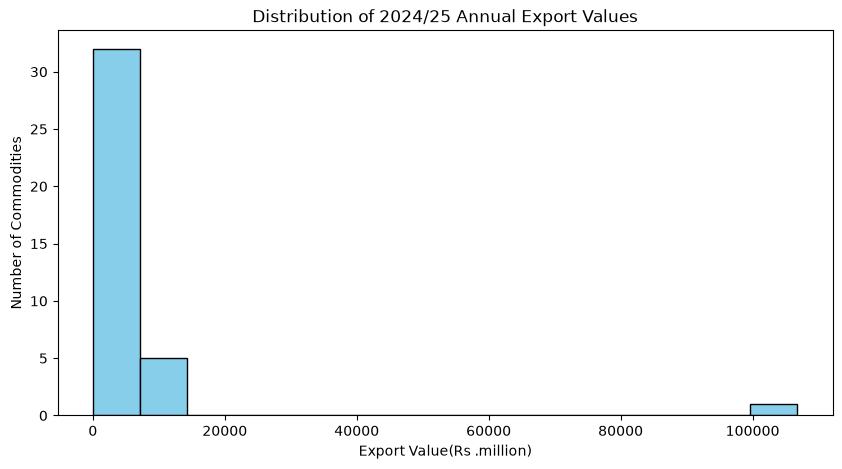

In [40]:
import matplotlib.pyplot as plt 


data = [
    "2023/24 Annual", "2023/24 Six Months",
    "2024/25 Annual", "2024/25 Six Months",
    "2025/26 Six Months"
]

#drwa histogram
plt.figure(figsize=(10,5))
plt.hist(df["2024/25 Annual"], bins=15, color="skyblue", edgecolor="black")
plt.title("Distribution of 2024/25 Annual Export Values")
plt.xlabel("Export Value(Rs .million)")
plt.ylabel("Number of Commodities")
plt.show()

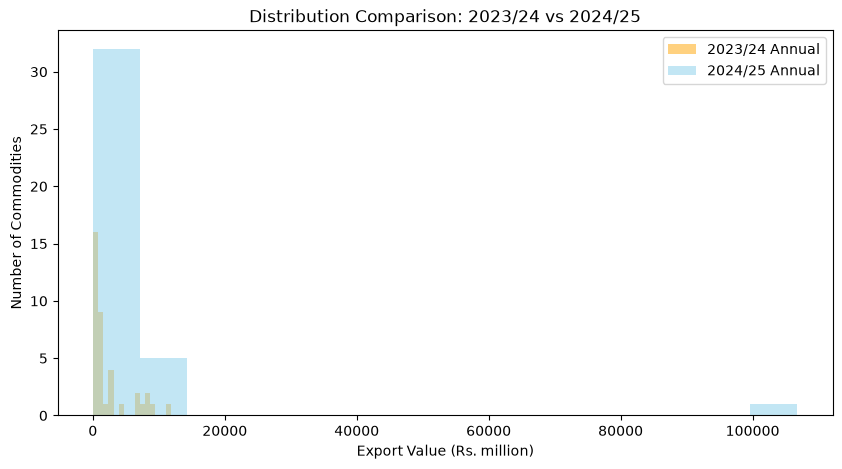

In [41]:
# Compare two years side by side (overlaid)
plt.figure(figsize=(10, 5))
plt.hist(df["2023/24 Annual"], bins=15, alpha=0.5, label="2023/24 Annual", color="orange")
plt.hist(df["2024/25 Annual"], bins=15, alpha=0.5, label="2024/25 Annual", color="skyblue")
plt.title("Distribution Comparison: 2023/24 vs 2024/25")
plt.xlabel("Export Value (Rs. million)")
plt.ylabel("Number of Commodities")
plt.legend()
plt.show()

In [48]:
# coefficent of variation
print("Coefficient of Variation (CV = std / mean)\n")

for d in data:
    mean_value = df[d].mean()
    std_value = df[d].std()
    cv = std_value / mean_value #as a ratio
    cv_percnetage = cv * 100 # as percetnage using formula

    print(f"{d}")
    print(f" Mean {mean_value:.2f} Std: {std_value:.2f}")
    print(f" CV: {cv:.2f} ({cv_percnetage:.1f}%\n")

Coefficient of Variation (CV = std / mean)

2023/24 Annual
 Mean 2337.28 Std: 3142.58
 CV: 1.34 (134.5%

2023/24 Six Months
 Mean 1166.86 Std: 1544.03
 CV: 1.32 (132.3%

2024/25 Annual
 Mean 5143.96 Std: 17236.06
 CV: 3.35 (335.1%

2024/25 Six Months
 Mean 1633.66 Std: 3282.77
 CV: 2.01 (200.9%

2025/26 Six Months
 Mean 2701.41 Std: 9060.13
 CV: 3.35 (335.4%



In [56]:
highest = df.loc[df["2023/24 Annual"].idxmax()]
print(highest)

lowest = df.loc[df["2024/25 Annual"].idxmin()]
print(lowest)

S.N.                            36
Commodities             Zinc sheet
2023/24 Annual         11858.04569
2023/24 Six Months     6085.189136
2024/25 Annual        10108.486376
2024/25 Six Months     4515.373418
2025/26 Six Months      702.792862
2024/25 Growth %         -25.79732
2025/26 Growth %        -84.435554
Growth                   58.638234
Name: 37, dtype: object
S.N.                           3
Commodities           Cattlefeed
2023/24 Annual             0.061
2023/24 Six Months         0.061
2024/25 Annual               0.0
2024/25 Six Months           0.0
2025/26 Six Months           0.0
2024/25 Growth %             NaN
2025/26 Growth %             NaN
Growth                       NaN
Name: 2, dtype: object


In [ ]:
#  TOP / BOTTOM N — nlargest() and nsmallest()
top5 = df.nlargest(5, "2024/25 Annual")
bottom5 = df.nsmallest(5, "2024/25 Annual")

print("Top 5 Commodities (2024/25 Annual):")
print(top5[["Commodities", "2024/25 Annual"]])

print("\nBottom 5 Commodities (2024/25 Annual):")
print(bottom5[["Commodities", "2024/25 Annual"]])


Top 5 Commodities (2024/25 Annual):
      Commodities  2024/25 Annual
29   Soyabean Oil   106790.819514
24  Polyster Yarn    12335.018810
37     Zinc sheet    10108.486376
11     Jute Goods     8222.942050
10          Juice     7703.781897

Bottom 5 Commodities (2024/25 Annual):
          Commodities  2024/25 Annual
2          Cattlefeed        0.000000
16  Mustard & Linseed        0.000000
5              Fruits        8.545120
20              Paper        9.571725
8    Handicraft Goods       13.902555


In [ ]:
# commodities ranking base of amount
ranked = df.sort_values("2024/25 Annual", ascending=False).reset_index(drop=True)
ranked.index = ranked.index + 1   # start rank at 1 instead of 0
print("\nFull Ranking (2024/25 Annual, highest to lowest):")
print(ranked[["Commodities", "2024/25 Annual"]])


Full Ranking (2024/25 Annual, highest to lowest):
              Commodities  2024/25 Annual
1            Soyabean Oil   106790.819514
2           Polyster Yarn    12335.018810
3              Zinc sheet    10108.486376
4              Jute Goods     8222.942050
5                   Juice     7703.781897
6                Cardamom     7674.036648
7          Particle Board     7099.647606
8    Jute Goods - Hessian     5690.120311
9                     Tea     3983.289142
10              Oil Cakes     3629.816606
11               Textiles     3091.284691
12  Jute Goods - Sackings     2532.821739
13               Palm Oil     2414.300633
14                  Rosin     2058.685252
15      Shoes and Sandals     2000.122154
16   Medicine (Ayurvedic)     1755.005277
17                  Herbs     1605.870861
18                Noodles     1396.572411
19                 Thread     1244.962596
20        Copper Wire Rod      846.129399
21            Tooth Paste      756.395088
22              G.I. pipe

In [74]:
# ascending order from lowest to highest
ranked_low_to_high = df["2023/24 Annual"].sort_values(ascending=True)
ranked_low_to_high

16        0.000000
2         0.061000
14       12.321872
5        16.845366
8        26.731749
20       30.903588
23       38.598926
28       97.240418
22      108.446434
35      182.190044
25      199.656821
3       201.032928
34      235.099011
0       427.451094
36      636.367546
33      781.835195
6       794.259648
29      901.804751
4       913.181691
17      924.010934
7      1127.290725
27     1277.710039
9      1342.547057
26     1478.585915
15     1544.098898
32     1827.586858
31     2542.391758
13     2715.206212
18     2955.789925
30     3093.406264
12     4040.570144
19     6336.478678
11     6755.776356
21     7415.322247
1      7936.619600
10     8658.685444
24     9382.523442
37    11858.045690
Name: 2023/24 Annual, dtype: float64

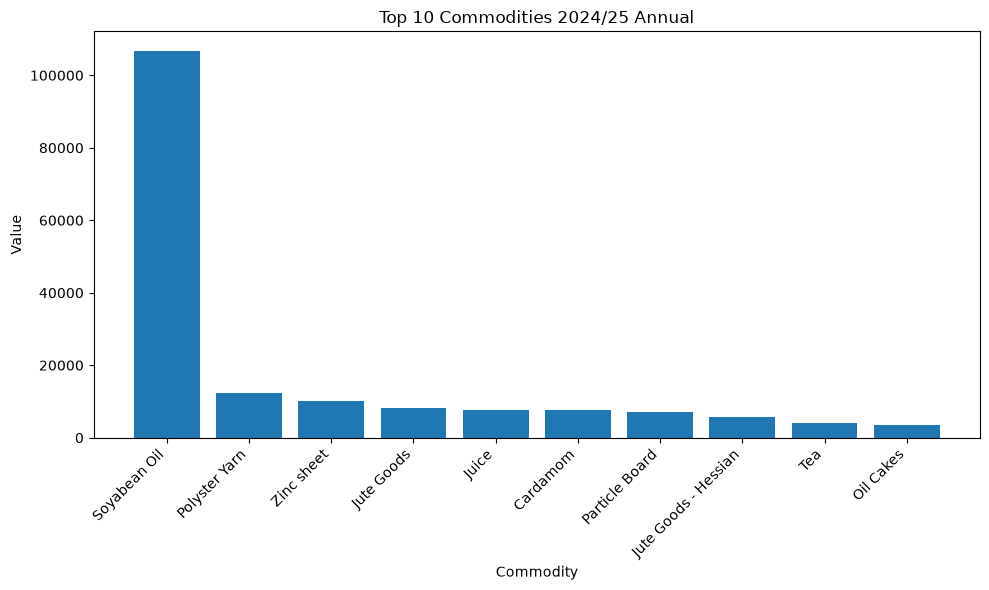

In [79]:
# select the 10 rows with largest value in column 3
top10 = df.nlargest(10, "2024/25 Annual")
# create a figure with a width of 10 inches and height 0f 6 inches
plt.figure(figsize = (10, 6))

# create a bar chart
# x -axis: comodity names (columns 2)
# y-axis:Values(column(3))
plt.bar(top10["Commodities"], top10["2024/25 Annual"])

plt.xlabel("Commodity")
plt.ylabel("Value")
plt.title("Top 10 Commodities 2024/25 Annual")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

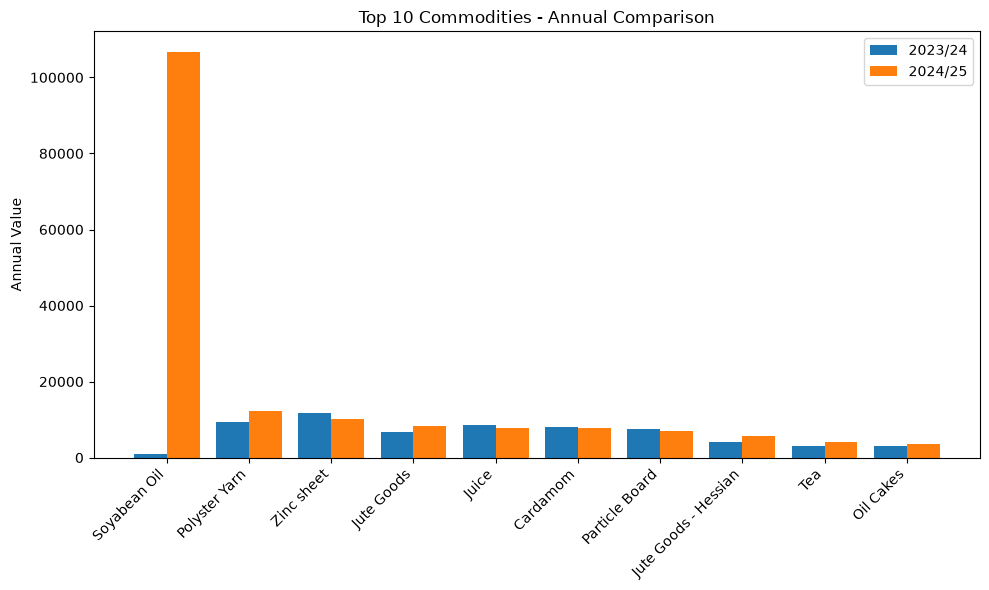


Highest 2024/25 Annual exporter:
Commodities        Soyabean Oil
2024/25 Annual    106790.819514
Name: 29, dtype: object

Lowest 2024/25 Annual exporter:
Commodities       Cattlefeed
2024/25 Annual           0.0
Name: 2, dtype: object

Highest commodity: Soyabean Oil
Lowest commodity: Cattlefeed


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_annual = top10[['Commodities', '2023/24 Annual', '2024/25 Annual']]

labels = df_annual['Commodities'].tolist()
x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - width/2, df_annual['2023/24 Annual'], width, label='2023/24')
ax.bar(x + width/2, df_annual['2024/25 Annual'], width, label='2024/25')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

ax.set_ylabel("Annual Value")
ax.set_title("Top 10 Commodities - Annual Comparison")
ax.legend()

plt.tight_layout()
plt.show()


max_row_idx = df["2024/25 Annual"].idxmax() #show which row has highest value
min_row_idx = df["2024/25 Annual"].idxmin() #show which row has lowest value



highest = df.loc[max_row_idx] #highest commodites of all year
lowest  = df.loc[min_row_idx]#lowest commodites of all year


print(f"\nHighest 2024/25 Annual exporter:\n{highest[['Commodities', '2024/25 Annual']]}")
print(f"\nLowest 2024/25 Annual exporter:\n{lowest[['Commodities', '2024/25 Annual']]}")

# it shows  the commodity name only
print("\nHighest commodity:", df.loc[df['2024/25 Annual'].idxmax(), 'Commodities'])
print("Lowest commodity:", df.loc[df['2024/25 Annual'].idxmin(), 'Commodities'])

0.1015546023510467


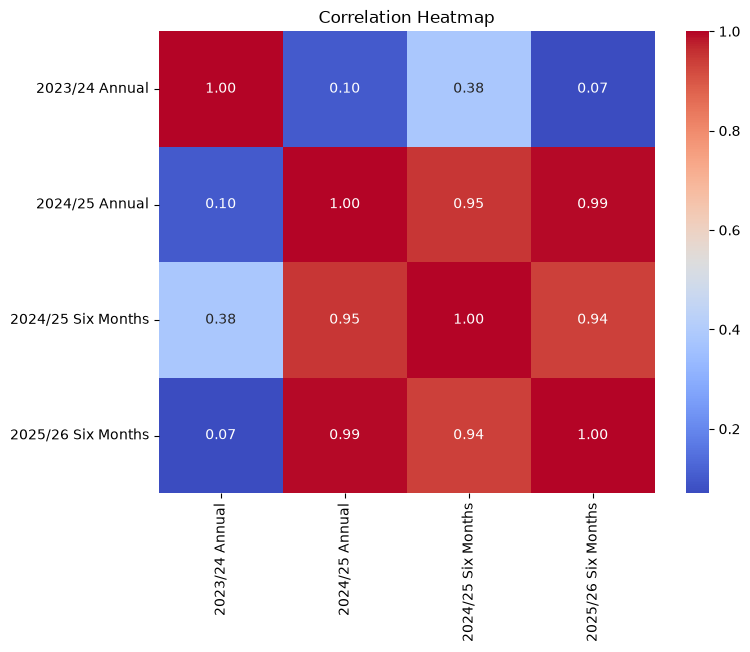

In [ ]:
corr1 = df["2023/24 Annual"].corr(df["2024/25 Annual"])

print(corr1)

import seaborn as sns
import matplotlib.pyplot as plt


cols = [
    "2023/24 Annual",
    "2024/25 Annual",
    "2024/25 Six Months",
    "2025/26 Six Months"
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

       Commodities  2023/24 Annual  2024/25 Annual    Growth %
0            Brans      427.451094      266.665181  -37.615043
1         Cardamom     7936.619600     7674.036648   -3.308499
2       Cattlefeed        0.061000        0.000000 -100.000000
3         Cinnamon      201.032928      174.522707  -13.187004
4  Copper Wire Rod      913.181691      846.129399   -7.342711

Top 5 Fastest Growing Commodities:
          Commodities  2023/24 Annual  2024/25 Annual      Growth %
29       Soyabean Oil      901.804751   106790.819514  11741.900297
23   Plastic Utensils       38.598926      130.543714    238.205560
14        Marble Slab       12.321872       22.205627     80.213095
34         Turpentine      235.099011      402.492225     71.201156
27  Shoes and Sandals     1277.710039     2000.122154     56.539598

Top 5 Most Declined Commodities:
   Commodities  2023/24 Annual  2024/25 Annual    Growth %
2   Cattlefeed        0.061000        0.000000 -100.000000
36        Wire      636.36

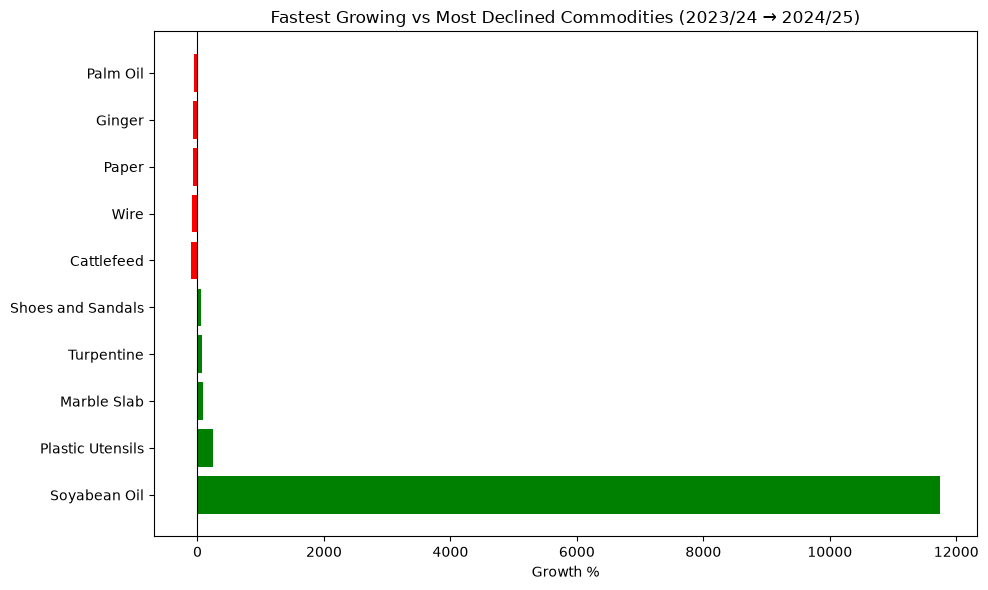


Commodities with positive growth: 16
Commodities with negative growth: 21
Commodities with zero growth:     0
Commodities with missing/undefined growth: 1


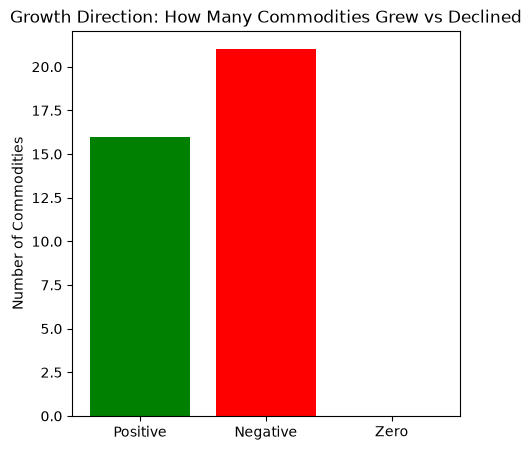

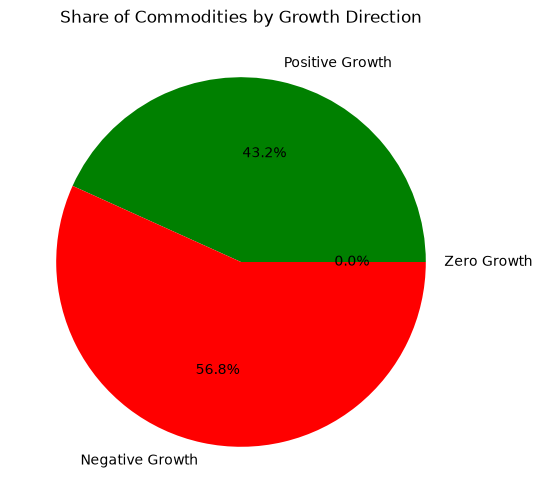

In [95]:
import matplotlib.pyplot as plt

# 1. GROWTH % — (new - old) / old * 100
# You already have this from your notebook, but here it is clean:
df["Growth %"] = (df["2024/25 Annual"] - df["2023/24 Annual"]) / df["2023/24 Annual"] * 100

# Watch out: this will produce inf/NaN if 2023/24 Annual is 0 (e.g. Mustard & Linseed)
# Replace infinities with NaN so they don't break later calculations
df["Growth %"] = df["Growth %"].replace([float("inf"), float("-inf")], pd.NA)

print(df[["Commodities", "2023/24 Annual", "2024/25 Annual", "Growth %"]].head())


# 2. FASTEST GROWING / MOST DECLINED — sort by Growth %
fastest_growing = df.sort_values("Growth %", ascending=False).head(5)
most_declined   = df.sort_values("Growth %", ascending=True).head(5)

print("\nTop 5 Fastest Growing Commodities:")
print(fastest_growing[["Commodities", "2023/24 Annual", "2024/25 Annual", "Growth %"]])

print("\nTop 5 Most Declined Commodities:")
print(most_declined[["Commodities", "2023/24 Annual", "2024/25 Annual", "Growth %"]])

# Visualize both together
top_bottom = pd.concat([fastest_growing, most_declined])

plt.figure(figsize=(10, 6))
colors = ["green" if x > 0 else "red" for x in top_bottom["Growth %"]]
plt.barh(top_bottom["Commodities"], top_bottom["Growth %"], color=colors)
plt.xlabel("Growth %")
plt.title("Fastest Growing vs Most Declined Commodities (2023/24 → 2024/25)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


# 3. POSITIVE VS NEGATIVE GROWTH COUNT — quick health check
positive_count = (df["Growth %"] > 0).sum()
negative_count = (df["Growth %"] < 0).sum()
zero_count     = (df["Growth %"] == 0).sum()
missing_count  = df["Growth %"].isna().sum()

print(f"\nCommodities with positive growth: {positive_count}")
print(f"Commodities with negative growth: {negative_count}")
print(f"Commodities with zero growth:     {zero_count}")
print(f"Commodities with missing/undefined growth: {missing_count}")

# Visualize as a simple bar
plt.figure(figsize=(5, 5))
plt.bar(["Positive", "Negative", "Zero"], [positive_count, negative_count, zero_count],
        color=["green", "red", "gray"])
plt.title("Growth Direction: How Many Commodities Grew vs Declined")
plt.ylabel("Number of Commodities")
plt.show()

# Or as a pie chart for proportion
plt.figure(figsize=(6, 6))
plt.pie(
    [positive_count, negative_count, zero_count],
    labels=["Positive Growth", "Negative Growth", "Zero Growth"],
    autopct="%1.1f%%",
    colors=["green", "red", "gray"]
)
plt.title("Share of Commodities by Growth Direction")
plt.show()

In [ ]:
cols = [
    "2023/24 Annual",
    "2024/25 Annual",
    "2023/24 Six Months",
    "2024/25 Six Months"
]

corr_matrix = df[cols].corr().round(2)
print(corr_matrix)

                    2023/24 Annual  2024/25 Annual  2023/24 Six Months  \
2023/24 Annual                1.00            0.10                0.99   
2024/25 Annual                0.10            1.00                0.10   
2023/24 Six Months            0.99            0.10                1.00   
2024/25 Six Months            0.38            0.95                0.38   

                    2024/25 Six Months  
2023/24 Annual                    0.38  
2024/25 Annual                    0.95  
2023/24 Six Months                0.38  
2024/25 Six Months                1.00  


In [ ]:
df.describe()

,S.N.,Commodities,2023/24 Annual,2023/24 Six Months,2024/25 Annual,2024/25 Six Months,2025/26 Six Months,2024/25 Growth %,2025/26 Growth %
count,36,38,38.000000,38.000000,38,38,38,35.000000,34.000000
unique,36,38,38.000000,38.000000,37,37,35,35.000000,34.000000
top,1,Brans,427.451094,304.162479,0,0,0,-49.837242,133.642592
freq,1,1,1.000000,1.000000,2,2,4,1.000000,1.000000


Correlation Matrix:
                    2023/24 Annual  2023/24 Six Months  2024/25 Annual  \
2023/24 Annual                1.00                0.99            0.10   
2023/24 Six Months            0.99                1.00            0.10   
2024/25 Annual                0.10                0.10            1.00   
2024/25 Six Months            0.38                0.38            0.95   
2025/26 Six Months            0.07                0.06            0.99   

                    2024/25 Six Months  2025/26 Six Months  
2023/24 Annual                    0.38                0.07  
2023/24 Six Months                0.38                0.06  
2024/25 Annual                    0.95                0.99  
2024/25 Six Months                1.00                0.94  
2025/26 Six Months                0.94                1.00  


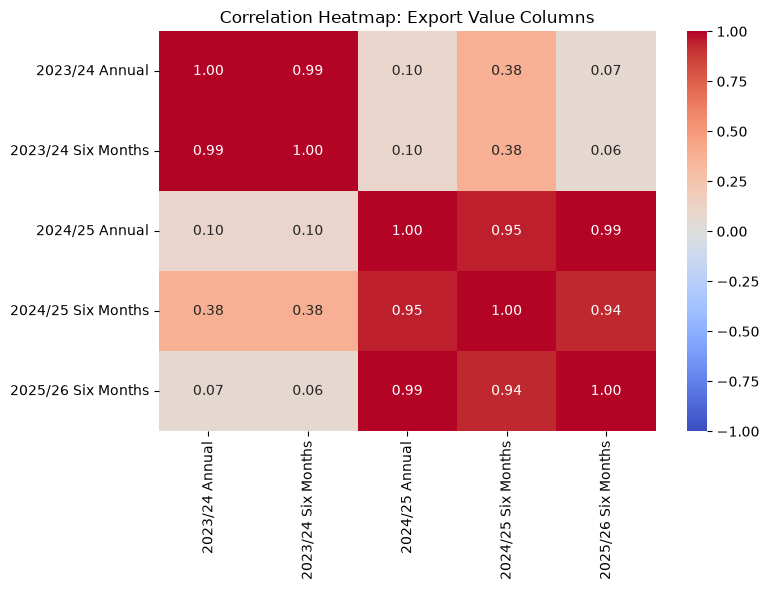

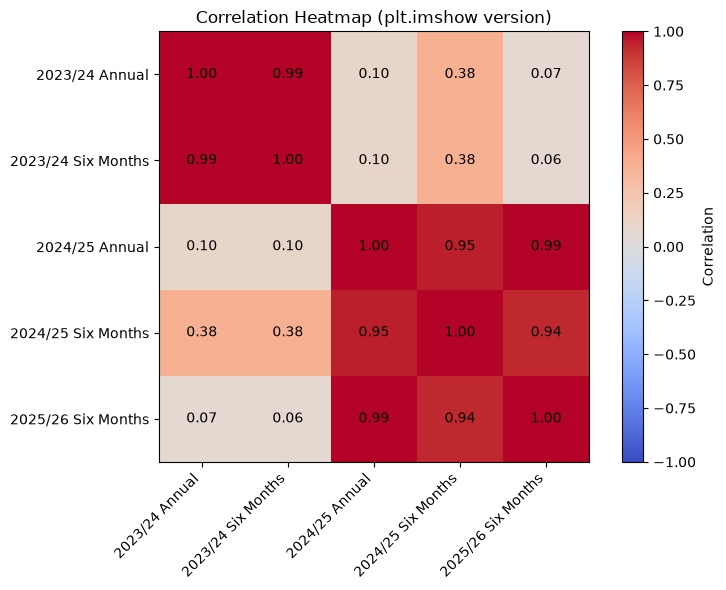

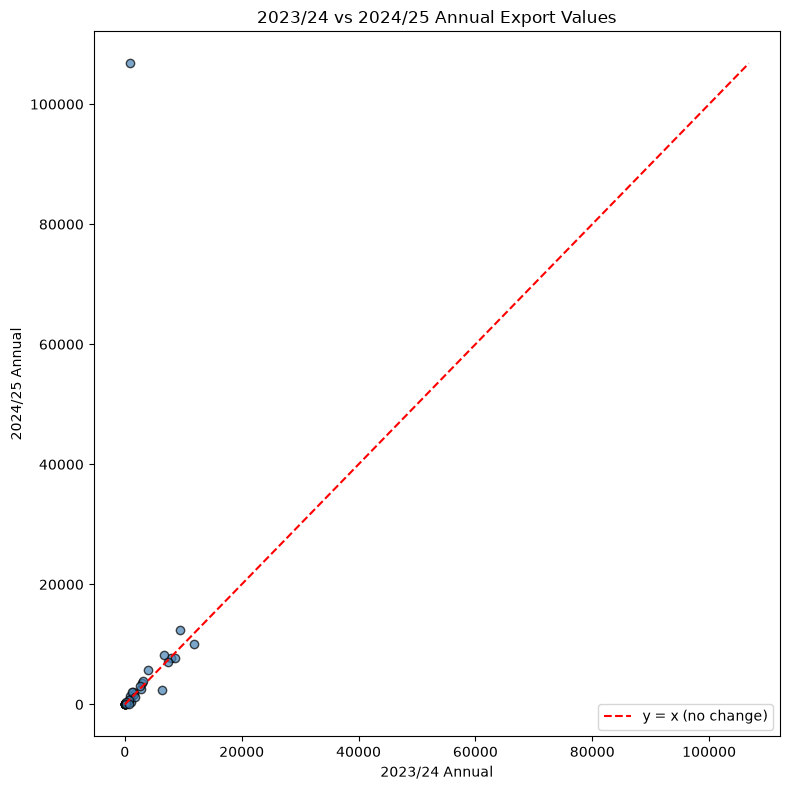

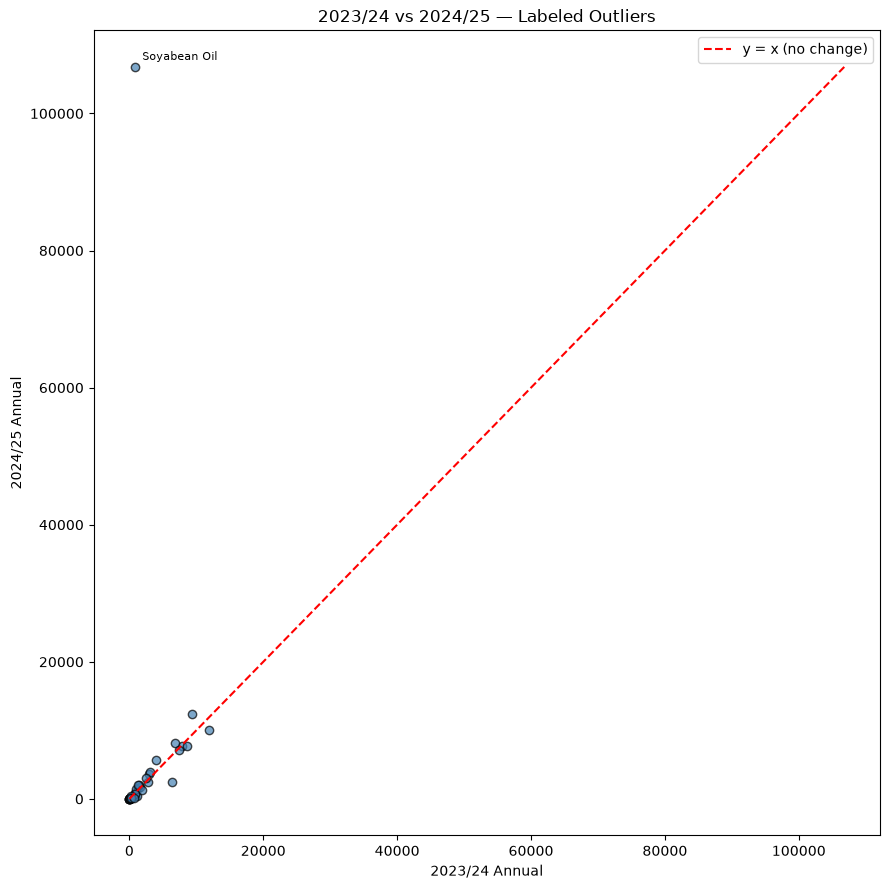

In [96]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = [
    "2023/24 Annual", "2023/24 Six Months",
    "2024/25 Annual", "2024/25 Six Months",
    "2025/26 Six Months"
]

# 1. CORRELATION MATRIX — .corr()
corr_matrix = df[numeric_cols].corr()
print("Correlation Matrix:")
print(corr_matrix.round(2))


# 2a. HEATMAP — using seaborn (easiest, nicest looking)
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Export Value Columns")
plt.tight_layout()
plt.show()


# 2b. HEATMAP — using plt.imshow() (no seaborn needed, more "from scratch")
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)

# Add the correlation numbers as text on each cell
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                  ha="center", va="center", color="black")

plt.title("Correlation Heatmap (plt.imshow version)")
plt.tight_layout()
plt.show()


# 3. SCATTER PLOT — 2023/24 vs 2024/25, with a reference diagonal line
x = df["2023/24 Annual"]
y = df["2024/25 Annual"]

plt.figure(figsize=(8, 8))
plt.scatter(x, y, color="steelblue", alpha=0.7, edgecolor="black")

# Diagonal reference line: y = x (perfect consistency between the two years)
max_val = max(x.max(), y.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="y = x (no change)")

plt.xlabel("2023/24 Annual")
plt.ylabel("2024/25 Annual")
plt.title("2023/24 vs 2024/25 Annual Export Values")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: label points that are far off the diagonal (biggest swings)
plt.figure(figsize=(9, 9))
plt.scatter(x, y, color="steelblue", alpha=0.7, edgecolor="black")
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="y = x (no change)")

for i, row in df.iterrows():
    # only label points that moved a lot, to avoid clutter
    if abs(row["2024/25 Annual"] - row["2023/24 Annual"]) > df["2024/25 Annual"].std():
        plt.annotate(row["Commodities"], (row["2023/24 Annual"], row["2024/25 Annual"]),
                     fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.xlabel("2023/24 Annual")
plt.ylabel("2024/25 Annual")
plt.title("2023/24 vs 2024/25 — Labeled Outliers")
plt.legend()
plt.tight_layout()
plt.show()

The bar chart sh

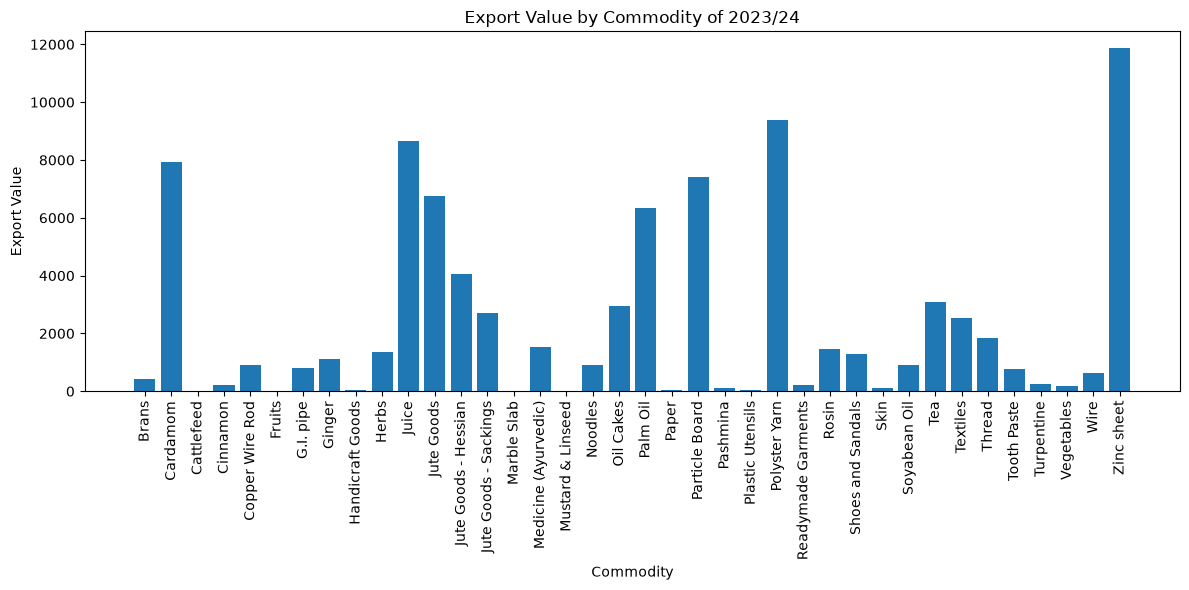

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(df["Commodities"], df["2023/24 Annual"])

plt.xlabel("Commodity")
plt.ylabel("Export Value")
plt.title("Export Value by Commodity of 2023/24")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

Zinch Sheet had the highest export value during 2023/24, followed by polyster yarn, while fruits accounted
for a comparatively smaller share of imports. The differences in bar heights indicate that import values varied substantially across commodities.

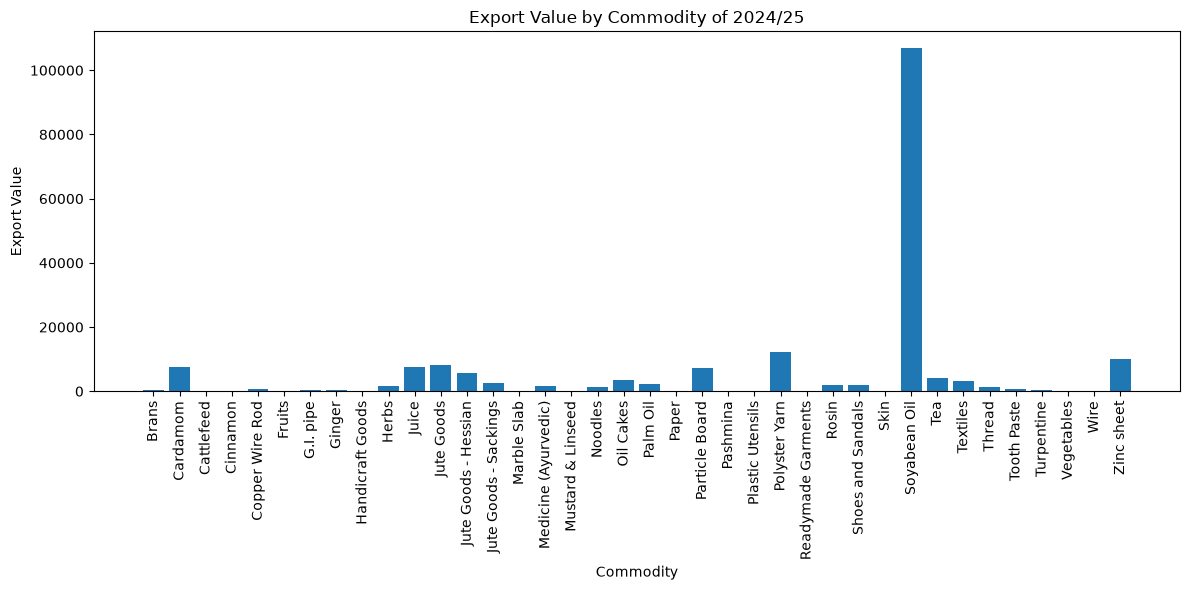

In [ ]:
plt.figure(figsize = (12,6))

plt.bar(df["Commodities"], df["2024/25 Annual"])

plt.xlabel("Commodity")
plt.ylabel("Export Value")
plt.title("Export Value by Commodity of 2024/25")

plt.xticks(rotation = 90)
plt.tight_layout()

Bar Chart Show Soyabean oil is the largest export commodity in 2024/25 year.

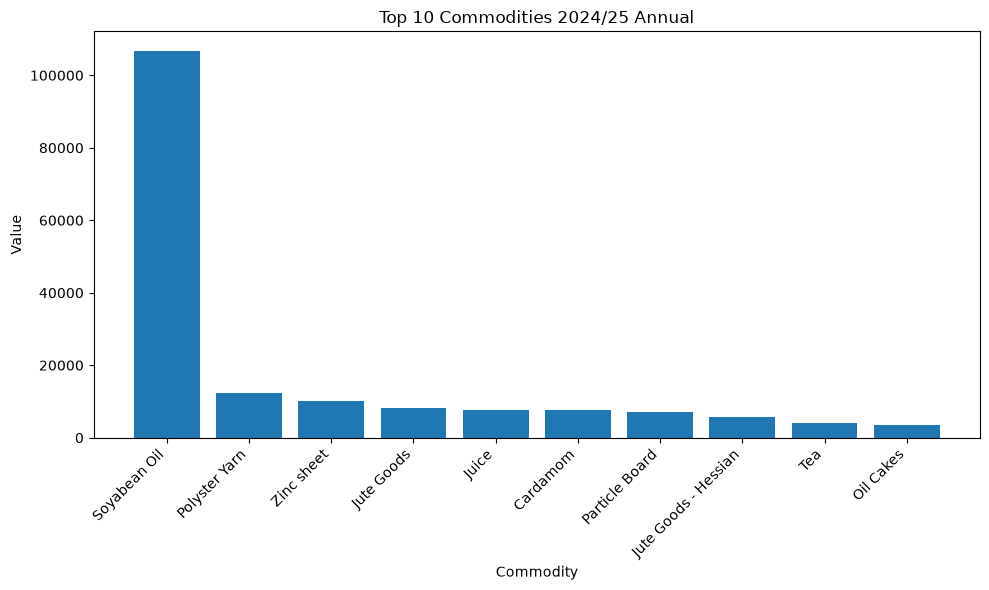

In [ ]:
print(top10)

    S.N.           Commodities  2023/24 Annual  2023/24 Six Months  \
29  28.0          Soyabean Oil      901.804751          415.193316   
24  23.0         Polyster Yarn     9382.523442         4548.345933   
37  36.0            Zinc sheet    11858.045690         6085.189136   
11  12.0            Jute Goods     6755.776356         3625.598887   
10  11.0                 Juice     8658.685444         3760.637317   
1    2.0              Cardamom     7936.619600         3907.678400   
21  20.0        Particle Board     7415.322247         3530.322941   
12   NaN  Jute Goods - Hessian     4040.570144         2145.910177   
30  29.0                   Tea     3093.406264         1865.805247   
18  17.0             Oil Cakes     2955.789925         1383.739179   

    2024/25 Annual  2024/25 Six Months  2025/26 Six Months  2024/25 Growth %  \
29   106790.819514        18909.958030        56082.425848               NaN   
24    12335.018810         5925.106407         5658.460047         30

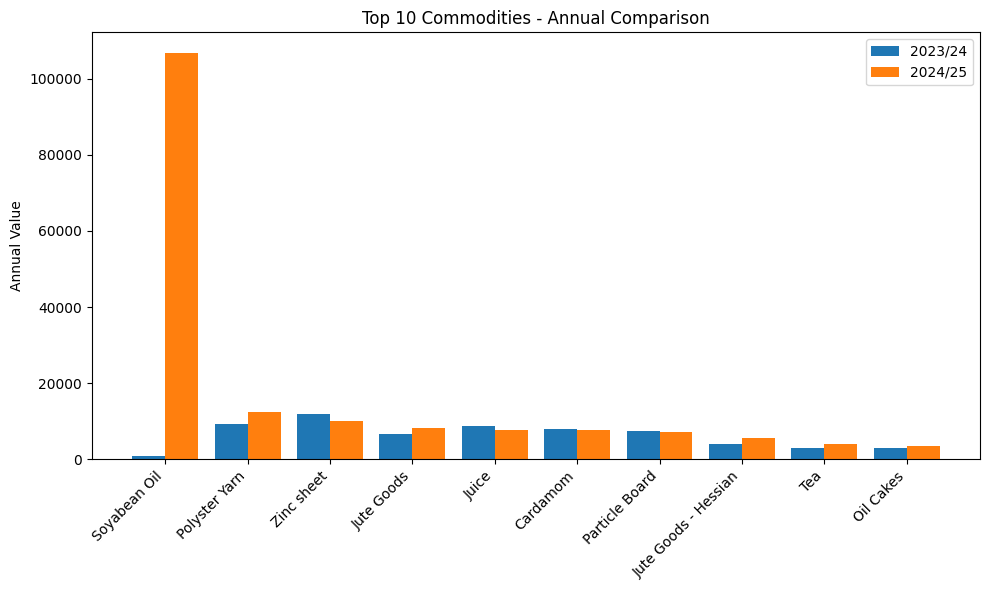

These above shows the top 10 commodities of 2024/25 Annual.

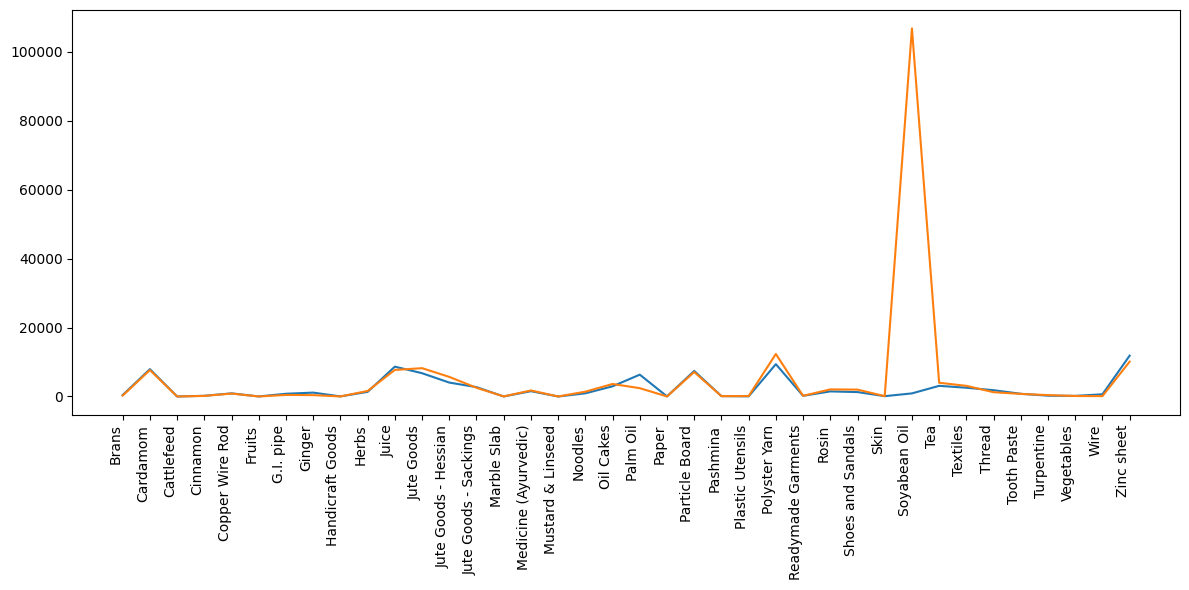

In [ ]:
plt.figure(figsize =(12,6))
plt.plot(df["Commodities"], df["2023/24 Annual"])
plt.plot(df["Commodities"], df["2024/25 Annual"])

plt.xticks(rotation=90, ha="right")
plt.tight_layout()

plt.show()


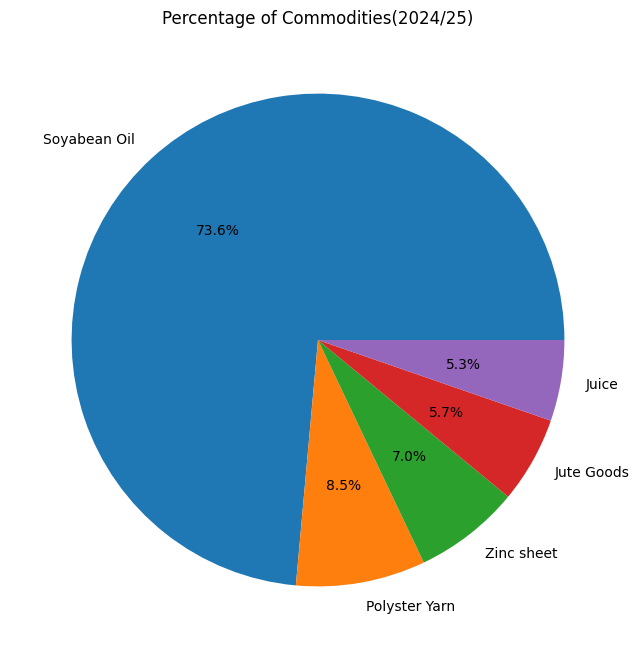

In [ ]:
top5 = df.nlargest(5, "2024/25 Annual")

plt.figure(figsize=(8,8))

plt.pie(
    top5["2024/25 Annual"],
    labels=top5["Commodities"],
    autopct="%1.1f%%",
)
plt.title("Percentage of Commodities(2024/25)")

plt.show()



Soyabean has highest export percentage among top5

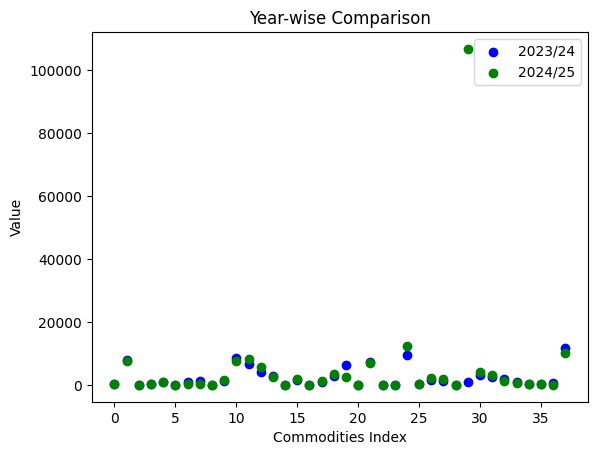

In [ ]:
plt.scatter(df.index, df["2023/24 Annual"], color="blue", label="2023/24")
plt.scatter(df.index, df["2024/25 Annual"], color="green", label="2024/25")

plt.xlabel("Commodities Index")
plt.ylabel("Value")
plt.title("Year-wise Comparison")
plt.legend()
plt.show()

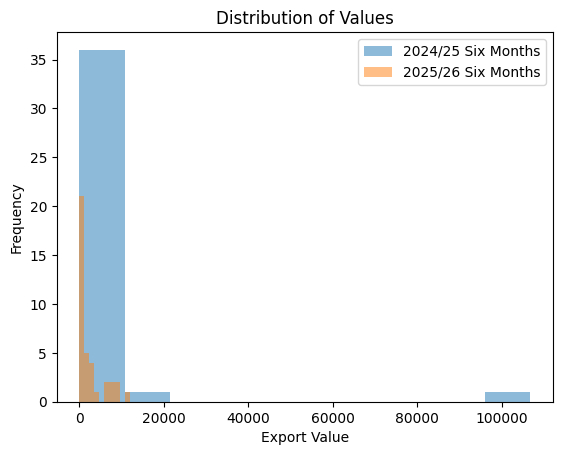

In [ ]:
plt.hist(df["2024/25 Annual"], bins=10, alpha=0.5, label="2024/25 Six Months")
plt.hist(df["2023/24 Annual"], bins=10, alpha=0.5, label="2025/26 Six Months")

plt.title("Distribution of Values")
plt.xlabel("Export Value")
plt.ylabel("Frequency")

plt.legend()

plt.show()

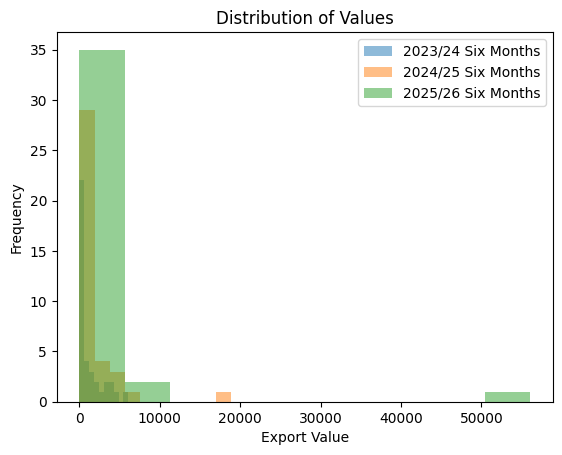

In [ ]:
plt.hist(df["2023/24 Six Months"], bins=10, alpha=0.5, label="2023/24 Six Months")
plt.hist(df["2024/25 Six Months"], bins=10, alpha=0.5, label="2024/25 Six Months")
plt.hist(df["2025/26 Six Months"], bins=10, alpha=0.5, label="2025/26 Six Months")

plt.title("Distribution of Values")
plt.xlabel("Export Value")
plt.ylabel("Frequency")

plt.legend()

plt.show()

In [ ]:
df[["2023/24 Annual", "2024/25 Annual"]].plot(kind="box")

NameError: name 'df' is not defined

In [ ]:
print(df.columns.tolist())

In [ ]:
print("hello")

hello


Q1 (25th percentile): 134.88
Q3 (75th percentile): 3495.18
IQR: 3360.30
Lower bound: -4905.57
Upper bound: 8535.63

IQR Outliers in '2024/25 Annual':
      Commodities  2024/25 Annual
24  Polyster Yarn    12335.018810
29   Soyabean Oil   106790.819514
37     Zinc sheet    10108.486376

Z-score Outliers in '2024/25 Annual' (|z| > 3):
     Commodities  2024/25 Annual   z_score
29  Soyabean Oil   106790.819514  5.897338

All commodities ranked by |z-score|:
              Commodities  2024/25 Annual   z_score
29           Soyabean Oil   106790.819514  5.897338
24          Polyster Yarn    12335.018810  0.417210
2              Cattlefeed        0.000000 -0.298442
16      Mustard & Linseed        0.000000 -0.298442
5                  Fruits        8.545120 -0.297946
20                  Paper        9.571725 -0.297886
8        Handicraft Goods       13.902555 -0.297635
14            Marble Slab       22.205627 -0.297153
28                   Skin       99.607004 -0.292663
22               Pash

<Figure size 800x600 with 0 Axes>

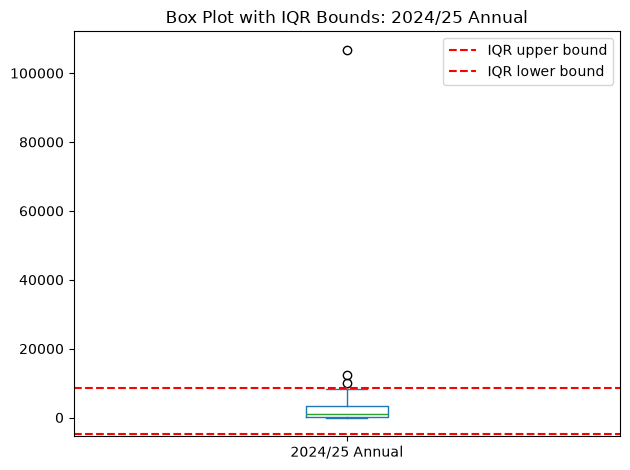

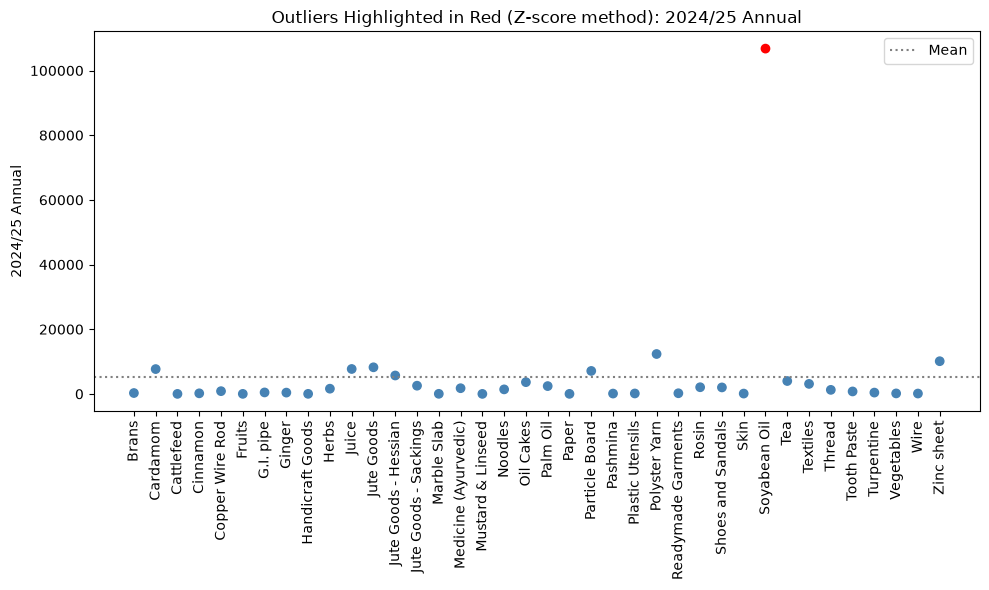


Mean 2024/25 Annual WITH outliers:    5143.96
Mean 2024/25 Annual WITHOUT outliers: 1892.46
Median 2024/25 Annual WITH outliers:    1045.55
Median 2024/25 Annual WITHOUT outliers: 756.40


In [97]:
import pandas as pd
import matplotlib.pyplot as plt

col = "2024/25 Annual"   # the column we suspect has an outlier (Soyabean Oil)


# 1. IQR METHOD
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

iqr_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"\nIQR Outliers in '{col}':")
print(iqr_outliers[["Commodities", col]])


# 2. Z-SCORE METHOD
mean_val = df[col].mean()
std_val = df[col].std()

df["z_score"] = (df[col] - mean_val) / std_val

z_outliers = df[df["z_score"].abs() > 3]
print(f"\nZ-score Outliers in '{col}' (|z| > 3):")
print(z_outliers[["Commodities", col, "z_score"]])

# See the z-scores for every commodity, sorted by extremity
print("\nAll commodities ranked by |z-score|:")
print(df[["Commodities", col, "z_score"]].reindex(df["z_score"].abs().sort_values(ascending=False).index))


# 3. VISUALIZE — box plot with outlier bounds marked
plt.figure(figsize=(8, 6))
df[[col]].plot(kind="box")
plt.axhline(upper_bound, color="red", linestyle="--", label="IQR upper bound")
plt.axhline(lower_bound, color="red", linestyle="--", label="IQR lower bound")
plt.title(f"Box Plot with IQR Bounds: {col}")
plt.legend()
plt.tight_layout()
plt.show()

# Scatter view: normal points vs outliers, color-coded
plt.figure(figsize=(10, 6))
colors = ["red" if abs(z) > 3 else "steelblue" for z in df["z_score"]]
plt.scatter(df["Commodities"], df[col], color=colors)
plt.xticks(rotation=90)
plt.axhline(mean_val, color="gray", linestyle=":", label="Mean")
plt.ylabel(col)
plt.title(f"Outliers Highlighted in Red (Z-score method): {col}")
plt.legend()
plt.tight_layout()
plt.show()


# 4. WHAT TO DO ABOUT IT — a version of the data WITHOUT the outlier,
#    so you can compare "with vs without" for mean/median/std
df_no_outliers = df[~df.index.isin(iqr_outliers.index)]

print(f"\nMean {col} WITH outliers:    {df[col].mean():.2f}")
print(f"Mean {col} WITHOUT outliers: {df_no_outliers[col].mean():.2f}")
print(f"Median {col} WITH outliers:    {df[col].median():.2f}")
print(f"Median {col} WITHOUT outliers: {df_no_outliers[col].median():.2f}")